In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# 1. อ่านไฟล์ข้อมูล
df = pd.read_csv('data.csv')

# 2. ฟังก์ชันลบ Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return df.drop(outliers.index)

df_cleaned = remove_outliers(df, 'Weight')
df_cleaned = remove_outliers(df_cleaned, 'Height')

# 3. เติมค่าว่าง
df_cleaned['Weight'] = df_cleaned['Weight'].fillna(df_cleaned['Weight'].mean())
df_cleaned['Height'] = df_cleaned['Height'].fillna(df_cleaned['Height'].mean())

# 4. Feature Scaling
X = df_cleaned[['Weight', 'Height']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. เทรน K-Means (K=3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_cleaned['Cluster'] = kmeans.fit_predict(X_scaled)

# 6. เทรน SVM โดยใช้ Cluster เป็น Target (y)
y = df_cleaned['Cluster']
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

print("เตรียมตัวแปรและเทรนโมเดลสำเร็จแล้ว!")

เตรียมตัวแปรและเทรนโมเดลสำเร็จแล้ว!


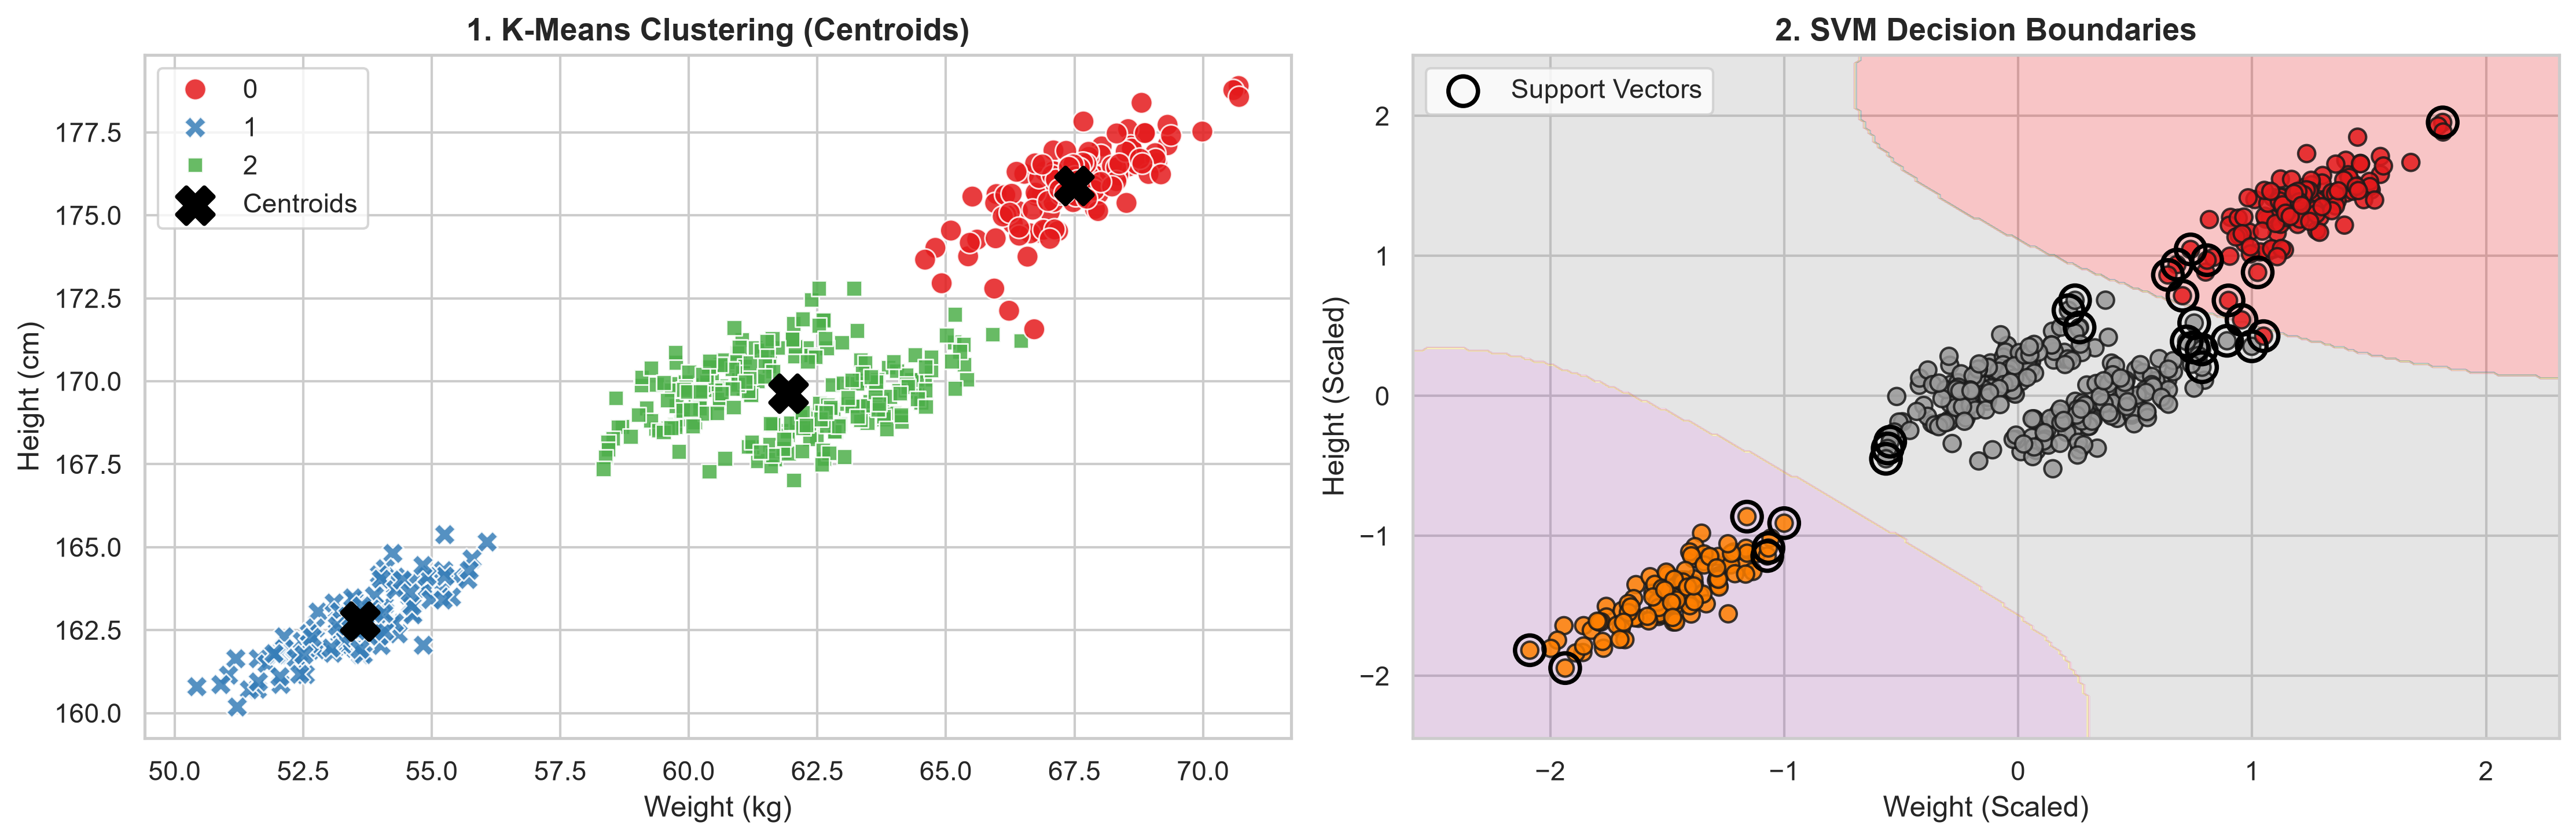

สร้างกราฟสำเร็จ!
บันทึกไฟล์: Graph1_Side_by_Side.png


In [7]:

# =========================================================
# Graph 1: Side-by-Side Comparison
# =========================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=300)

# 1. K-Means Plot
sns.scatterplot(
    data=df_cleaned,
    x='Weight',
    y='Height',
    hue='Cluster',
    style='Cluster',
    palette='Set1',
    s=80,
    alpha=0.85,
    ax=axes[0]
)

# แสดงตำแหน่ง Centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

axes[0].scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='black',
    s=220,
    marker='X',
    linewidths=2,
    label='Centroids'
)

axes[0].set_title(
    '1. K-Means Clustering (Centroids)',
    fontsize=13,
    fontweight='bold'
)
axes[0].set_xlabel('Weight (kg)')
axes[0].set_ylabel('Height (cm)')
axes[0].legend(loc='upper left')

# 2. SVM Plot
h = 0.02

x_min = X_scaled[:, 0].min() - 0.5
x_max = X_scaled[:, 0].max() + 0.5
y_min = X_scaled[:, 1].min() - 0.5
y_max = X_scaled[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# ทำนาย Cluster ในแต่ละตำแหน่ง
Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# แสดง Decision Boundaries
axes[1].contourf(
    xx,
    yy,
    Z,
    alpha=0.25,
    cmap='Set1'
)

# แสดงข้อมูลทั้งหมด
axes[1].scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y,
    cmap='Set1',
    edgecolors='k',
    s=50,
    alpha=0.85
)

# แสดง Support Vectors
axes[1].scatter(
    svm_model.support_vectors_[:, 0],
    svm_model.support_vectors_[:, 1],
    s=150,
    facecolors='none',
    edgecolors='black',
    linewidths=1.8,
    label='Support Vectors'
)

axes[1].set_title(
    '2. SVM Decision Boundaries',
    fontsize=13,
    fontweight='bold'
)
axes[1].set_xlabel('Weight (Scaled)')
axes[1].set_ylabel('Height (Scaled)')
axes[1].legend(loc='upper left')

# บันทึกและแสดงกราฟ
plt.tight_layout()
plt.savefig(
    'Graph1_Side_by_Side.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("สร้างกราฟสำเร็จ!")
print("บันทึกไฟล์: Graph1_Side_by_Side.png")


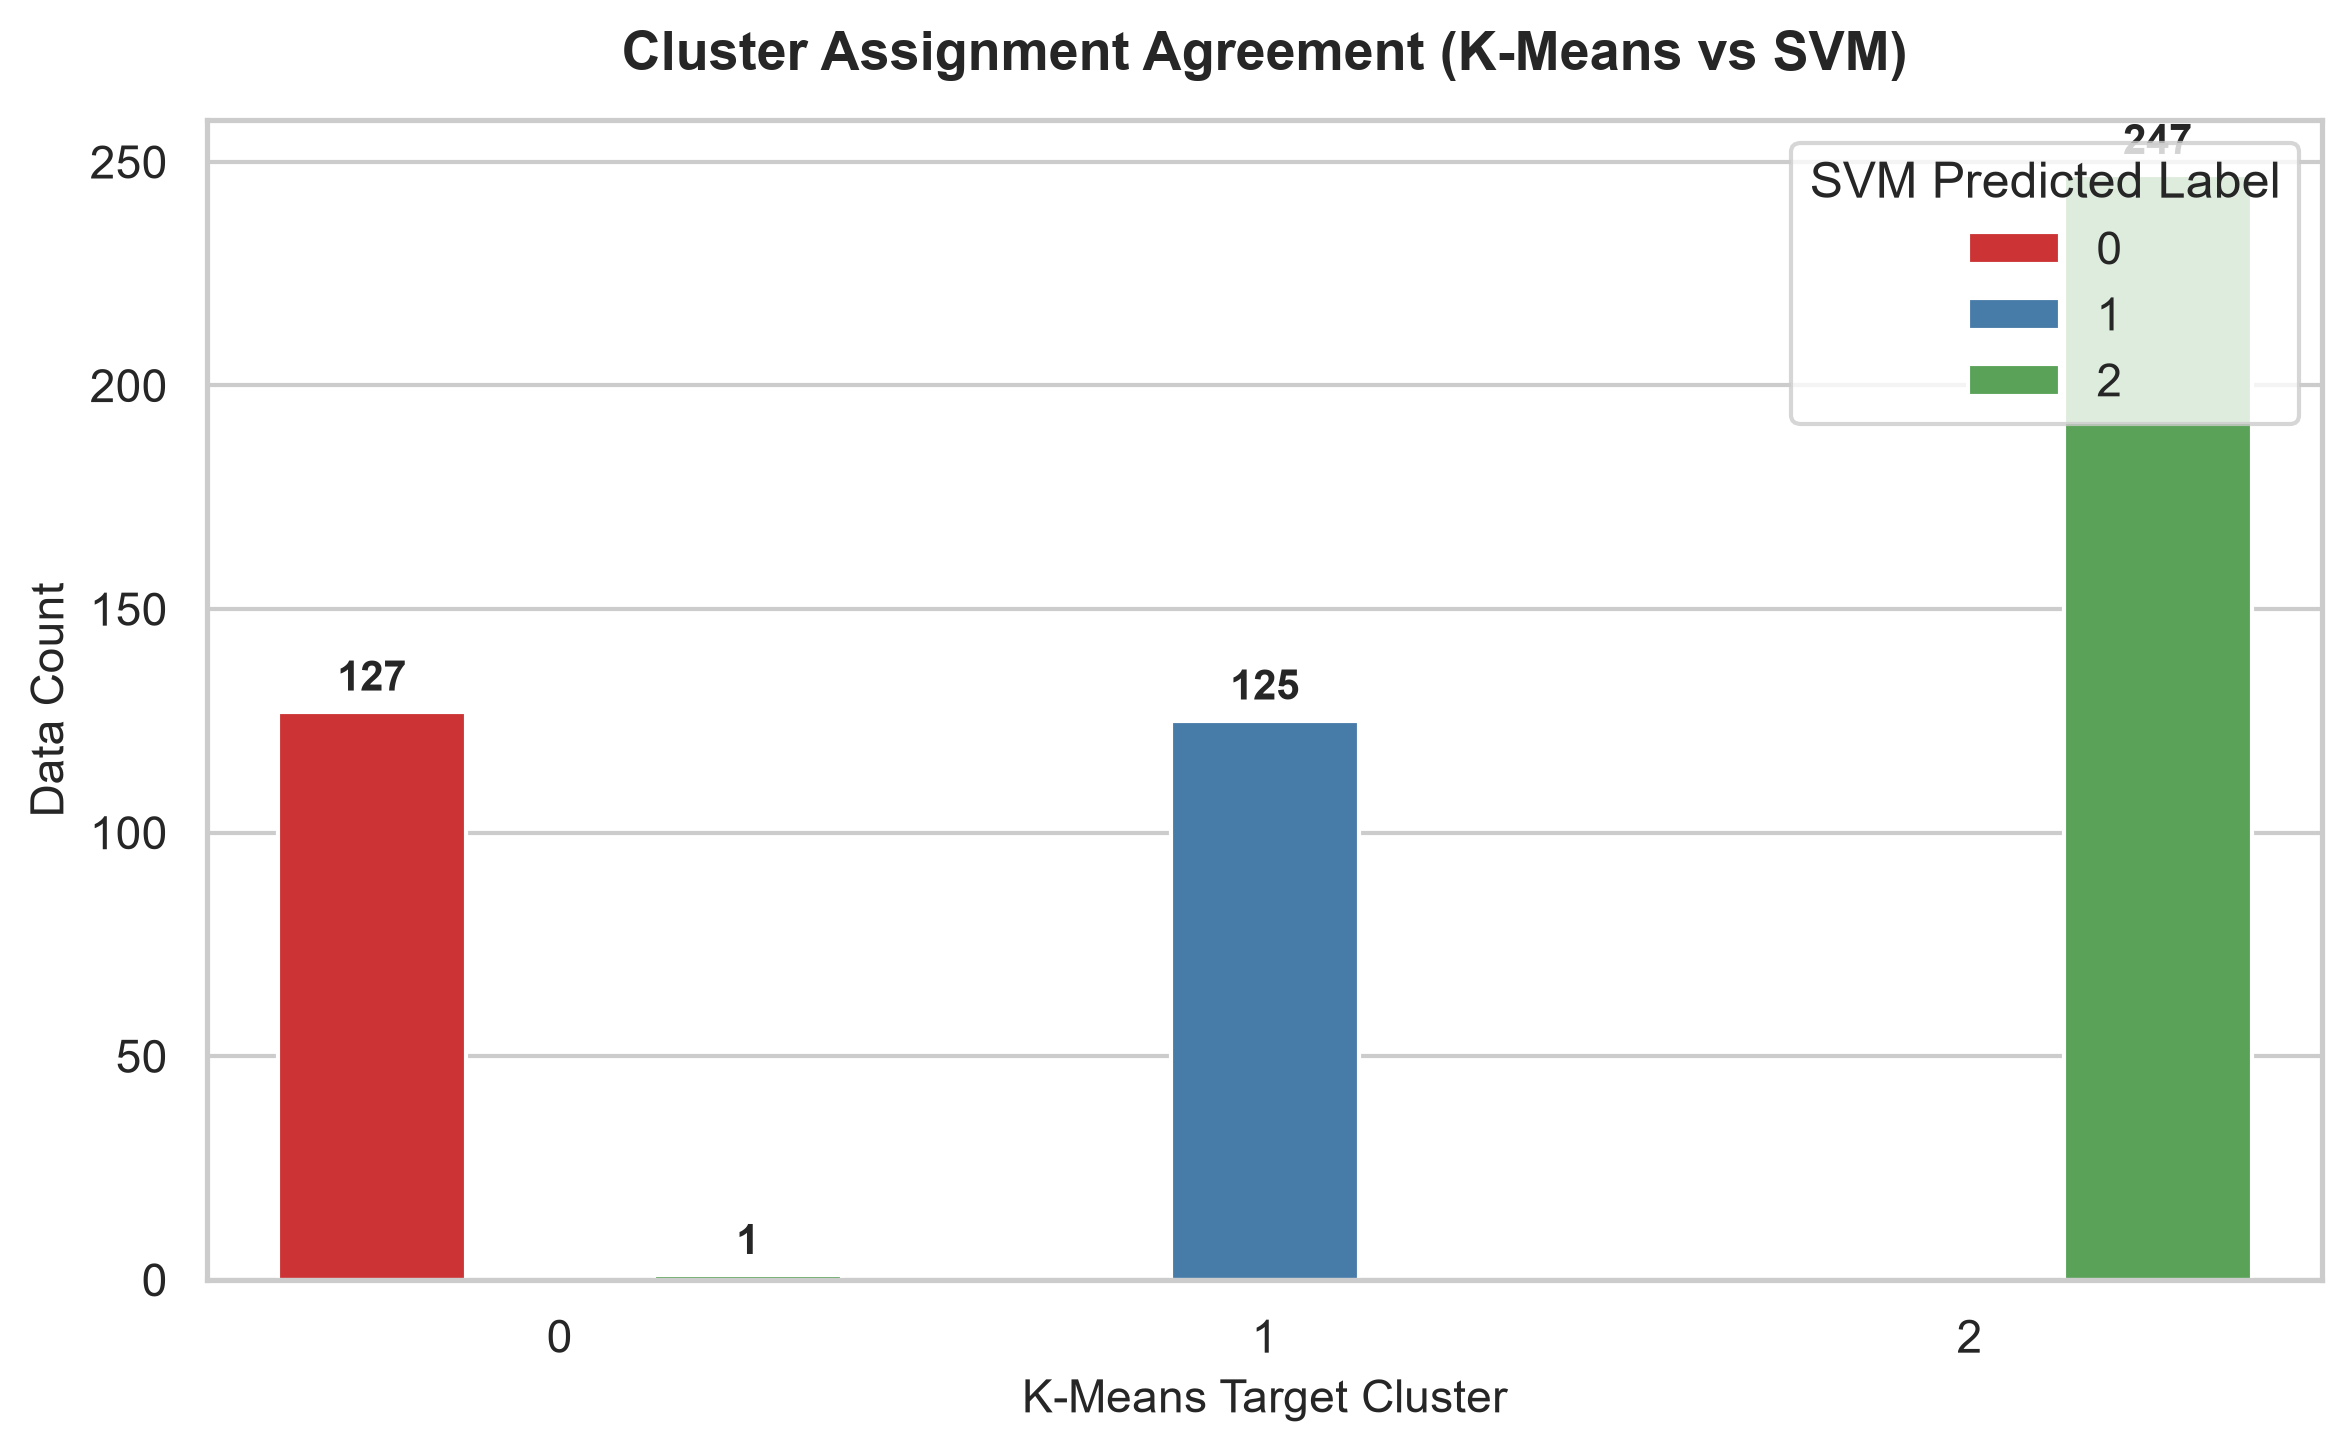

In [8]:
# =========================================================
# Graph 2: Cluster Assignment Agreement
# =========================================================
y_all_pred = svm_model.predict(X_scaled)
df_compare = pd.DataFrame({'K-Means Cluster': y, 'SVM Prediction': y_all_pred})

plt.figure(figsize=(8, 5), dpi=300)
ax = sns.countplot(data=df_compare, x='K-Means Cluster', hue='SVM Prediction', palette='Set1')

# ใส่ตัวเลขบนแท่งกราฟ
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3),
                    textcoords='offset points')

plt.title('Cluster Assignment Agreement (K-Means vs SVM)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('K-Means Target Cluster', fontsize=11)
plt.ylabel('Data Count', fontsize=11)
plt.legend(title='SVM Predicted Label', loc='upper right')
plt.tight_layout()
plt.savefig('Graph2_Cluster_Agreement.png', dpi=300, bbox_inches='tight')
plt.show()